## Lung UTE Scan Preparation

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/Packages/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))

sys.path.insert(0, "/home/rinbha/Research/BPT/BPT_MOTUS/nonrigid-motion-bpt")
sys.path.insert(0, "/home/rinbha/Research/BPT/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/torch-interpol")
import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import numpy as np

# plotting
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

#### AIR Coil BPT Sweeps

In [ ]:
from bpt_motus.io import bSSFPArchive
from bpt_motus.preprocessing import SplitXkBPT

In [ ]:
# Path to bSSFP ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040926/Exam54415/Series3"

# Create the object
bssfp = bSSFPArchive(inpdir)
bssfp.get_metadata(force_reload=False)
bssfp.get_ksp(force_reload=False)

# Split into xk and BPT
split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)
split_xk_bpt.num_bpts = 1
split_xk_bpt.xk_raw_fname = "xk_time.npy"
split_xk_bpt.run(force_reload=False)

print(f"xk_time shape: {bssfp.xk_time.shape}")
print(f"xk_recon shape: {bssfp.xk_recon.shape}")

INFO: Loading cached metadata from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040926/Exam54415/Series3/metadata_dict.pkl
INFO: Cached data not found / used — extracting k-space.


Extracting k-space:   0%|          | 0/275201 [00:00<?, ?it/s]

INFO: Cleaned k-space and raw BPT/PT signals not found. Extracting...
INFO: Getting raw time-ordered k-space.
INFO: Getting hybrid raw k-space.
INFO: Getting coarse peaks.
INFO: Getting strongest tone.
INFO: Getting offsets.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 275200/275200 [02:22<00:00, 1933.37it/s]
INFO: Aligning k-space.
INFO: Extracting BPT/PTs.
INFO: Cleaning k-space, still aligned.
INFO: Unaligning cleaned k-space.
INFO: Coil compressing k-space with PCA.


xk_time shape: (16, 275200, 256)
xk_recon shape: (256, 1075, 256, 16)


In [ ]:
def analyze_and_plot_steps(
    bpt,
    tr=1,
    shift=0,
    figsize=(12, 10),
    dpi=300,
    title="BPT",
    step_time=2.0,
    n_steps=116,
    f_start=1.2,
    f_stop=3.5,
    f_step=0.02,
    plot_f_start=None,
    plot_f_stop=None,
    save_path=None
):

    npe, ncoils = bpt.shape
    t = np.arange(npe) * tr

    # -----------------------------
    # 1. Pick strongest coil
    # -----------------------------
    coil_ranges = np.max(bpt, axis=0) - np.min(bpt, axis=0)
    best_coil = np.argmax(coil_ranges)

    signal = bpt[:, best_coil]

    # -----------------------------
    # 2. Detect jumps via first difference
    # -----------------------------
    diff = np.diff(signal)

    baseline_len = int(4 / tr)
    baseline = diff[:baseline_len]

    threshold = np.mean(np.abs(baseline)) + 5 * np.std(baseline)

    jump_indices = np.where(np.abs(diff) > threshold)[0]

    if len(jump_indices) == 0:
        print("No steps detected.")
        return

    # -----------------------------
    # 3. Drift correction (step_time refinement)
    # -----------------------------
    if len(jump_indices) > 1:
        detected_step_times = np.diff(jump_indices) * tr

        valid_steps = detected_step_times[
            (detected_step_times > 0.5 * step_time) &
            (detected_step_times < 1.5 * step_time)
        ]

        if len(valid_steps) > 0:
            step_time = np.median(valid_steps)

    start_idx = jump_indices[0] + 1
    start_time = start_idx * tr

    # -----------------------------
    # 4. Frequency mapping
    # -----------------------------
    freqs = f_start + np.arange(n_steps) * f_step
    t = np.arange(npe) * tr
    freq_axis = f_start + (t - start_time) / step_time * f_step

    # -----------------------------
    # 5. Print summary
    # -----------------------------
    print("-" * 30)
    print("EXPERIMENT SUMMARY")
    print(f"Best coil:     {best_coil}")
    print(f"Start time:    {start_time:.2f} s")
    print(f"Step spacing:  {step_time:.4f} s")
    print(f"Total steps:   {n_steps}")
    print(f"Freq range:    {f_start:.2f} → {f_stop:.2f} GHz")
    print("-" * 30)

    # -----------------------------
    # 6. Data scaling
    # -----------------------------
    if shift == 0:
        shift = 0.8 * np.max(np.abs(bpt))

    denom = shift if shift != 0 else 1

    offset_data = (
        (bpt - np.mean(bpt, axis=0)) / denom
        + np.arange(ncoils)
    )

    # -----------------------------
    # 7. Set plotting window (NEW)
    # -----------------------------
    if plot_f_start is None:
        plot_f_start = f_start
    if plot_f_stop is None:
        plot_f_stop = f_stop

    mask = (freq_axis >= plot_f_start) & (freq_axis <= plot_f_stop)

    freq_plot = freq_axis[mask]
    data_plot = offset_data[mask, :]

    # -----------------------------
    # 8. Plot
    # -----------------------------
    plt.figure(figsize=figsize, dpi=dpi)

    plt.plot(freq_plot, data_plot, lw=1.0)

    for f in freqs:
        if plot_f_start <= f <= plot_f_stop:
            plt.axvline(f, color='black', linestyle='--', alpha=0.25, lw=0.8)

    plt.title(f"{title} | zoom {plot_f_start:.2f}-{plot_f_stop:.2f} GHz")
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Signal")

    plt.xlim(plot_f_start, plot_f_stop)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()

    # -----------------------------
    # SAVE OR SHOW
    # -----------------------------
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [ ]:
# 041426: processing a bunch of old sweeps from last week
from bpt_motus.io.bssfp_reader import bSSFPArchive
from bpt_motus.preprocessing.split_xk_bpt import SplitXkBPT
import os

inpdirs = [
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series6",
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series7",
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series10",
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series11",
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s2/Exam54413/Series12",
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s2/Exam54413/Series13",
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s2/Exam54413/Series14",
    "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s2/Exam54413/Series15",
]

titles = [
    "BPT Sweep Spiral Antenna Under Mat Up 040826_s1",
    "BPT Sweep Spiral Antenna Coil Center Up 040826_s1",
    "BPT Sweep Spiral Antenna Coil Center Down 040826_s1",
    "BPT Sweep Spiral Antenna Bore Top Down 040826_s1",
    "BPT Sweep Spiral Antenna Bore Top Down 040826_s2",
    "BPT Sweep Spiral Antenna Coil Center Down 040826_s2",
    "BPT Sweep Spiral Antenna Coil Center Up 040826_s2",
    "BPT Sweep Spiral Antenna Under Mat Up 040826_s2",
]

for inpdir, title in zip(inpdirs, titles):
    print(f"\n=== Processing {inpdir} ===")

    try:
        # Load archive
        bssfp = bSSFPArchive(inpdir)
        bssfp.get_metadata(force_reload=False)
        bssfp.get_ksp(force_reload=False)

        # Split
        split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)
        split_xk_bpt.num_bpts = 1
        split_xk_bpt.xk_raw_fname = "xk_time.npy"
        split_xk_bpt.run(force_reload=False)

        # -----------------------------
        # NEW: plotting + saving
        # -----------------------------
        safe_title = title.replace(" ", "_")
        save_path = os.path.join(inpdir, f"{safe_title}.png")

        analyze_and_plot_steps(
            split_xk_bpt.bpts[0],
            figsize=(10, 10),
            tr=bssfp.metadata_dict['tr'],
            title=title,
            step_time=10.0,
            shift=0,
            n_steps=90,
            f_start=0.6,
            f_stop=2.4,
            f_step=0.02,
            plot_f_start=None,
            plot_f_stop=None,
            dpi=400,
            save_path=save_path
        )

        print(f"✅ Saved plot: {save_path}")

    except Exception as e:
        print(f"❌ Failed for {inpdir}")
        print(e)

INFO: Loading cached metadata from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series6/metadata_dict.pkl
INFO: Loading cached k-space from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series6



=== Processing /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series6 ===


INFO: Cleaned k-space and raw BPT/PT signals found. Opening...


------------------------------
EXPERIMENT SUMMARY
Best coil:     14
Start time:    15.52 s
Step spacing:  9.9525 s
Total steps:   90
Freq range:    0.60 → 2.40 GHz
------------------------------


INFO: Loading cached metadata from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s1/Exam54413/Series7/metadata_dict.pkl
INFO: Cached data not found / used — extracting k-space.


...

✅ Saved plot: /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s2/Exam54413/Series14/BPT_Sweep_Spiral_Antenna_Coil_Center_Up_040826_s2.png

=== Processing /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s2/Exam54413/Series15 ===


INFO: Cached data not found / used — extracting k-space.


Extracting k-space:   0%|          | 0/280833 [00:00<?, ?it/s]

INFO: Cleaned k-space and raw BPT/PT signals not found. Extracting...
INFO: Getting raw time-ordered k-space.
INFO: Getting hybrid raw k-space.
INFO: Getting coarse peaks.
INFO: Getting strongest tone.
INFO: Getting offsets.
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 280832/280832 [02:23<00:00, 1950.57it/s]
INFO: Aligning k-space.
INFO: Extracting BPT/PTs.
INFO: Cleaning k-space, still aligned.
INFO: Unaligning cleaned k-space.
INFO: Coil compressing k-space with PCA.


------------------------------
EXPERIMENT SUMMARY
Best coil:     11
Start time:    15.71 s
Step spacing:  9.9558 s
Total steps:   90
Freq range:    0.60 → 2.40 GHz
------------------------------
✅ Saved plot: /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_cardiac_040826_s2/Exam54413/Series15/BPT_Sweep_Spiral_Antenna_Under_Mat_Up_040826_s2.png


------------------------------
EXPERIMENT SUMMARY
Best coil:     6
Start time:    15.06 s
Step spacing:  9.7940 s
Total steps:   90
Freq range:    0.60 → 2.40 GHz
------------------------------


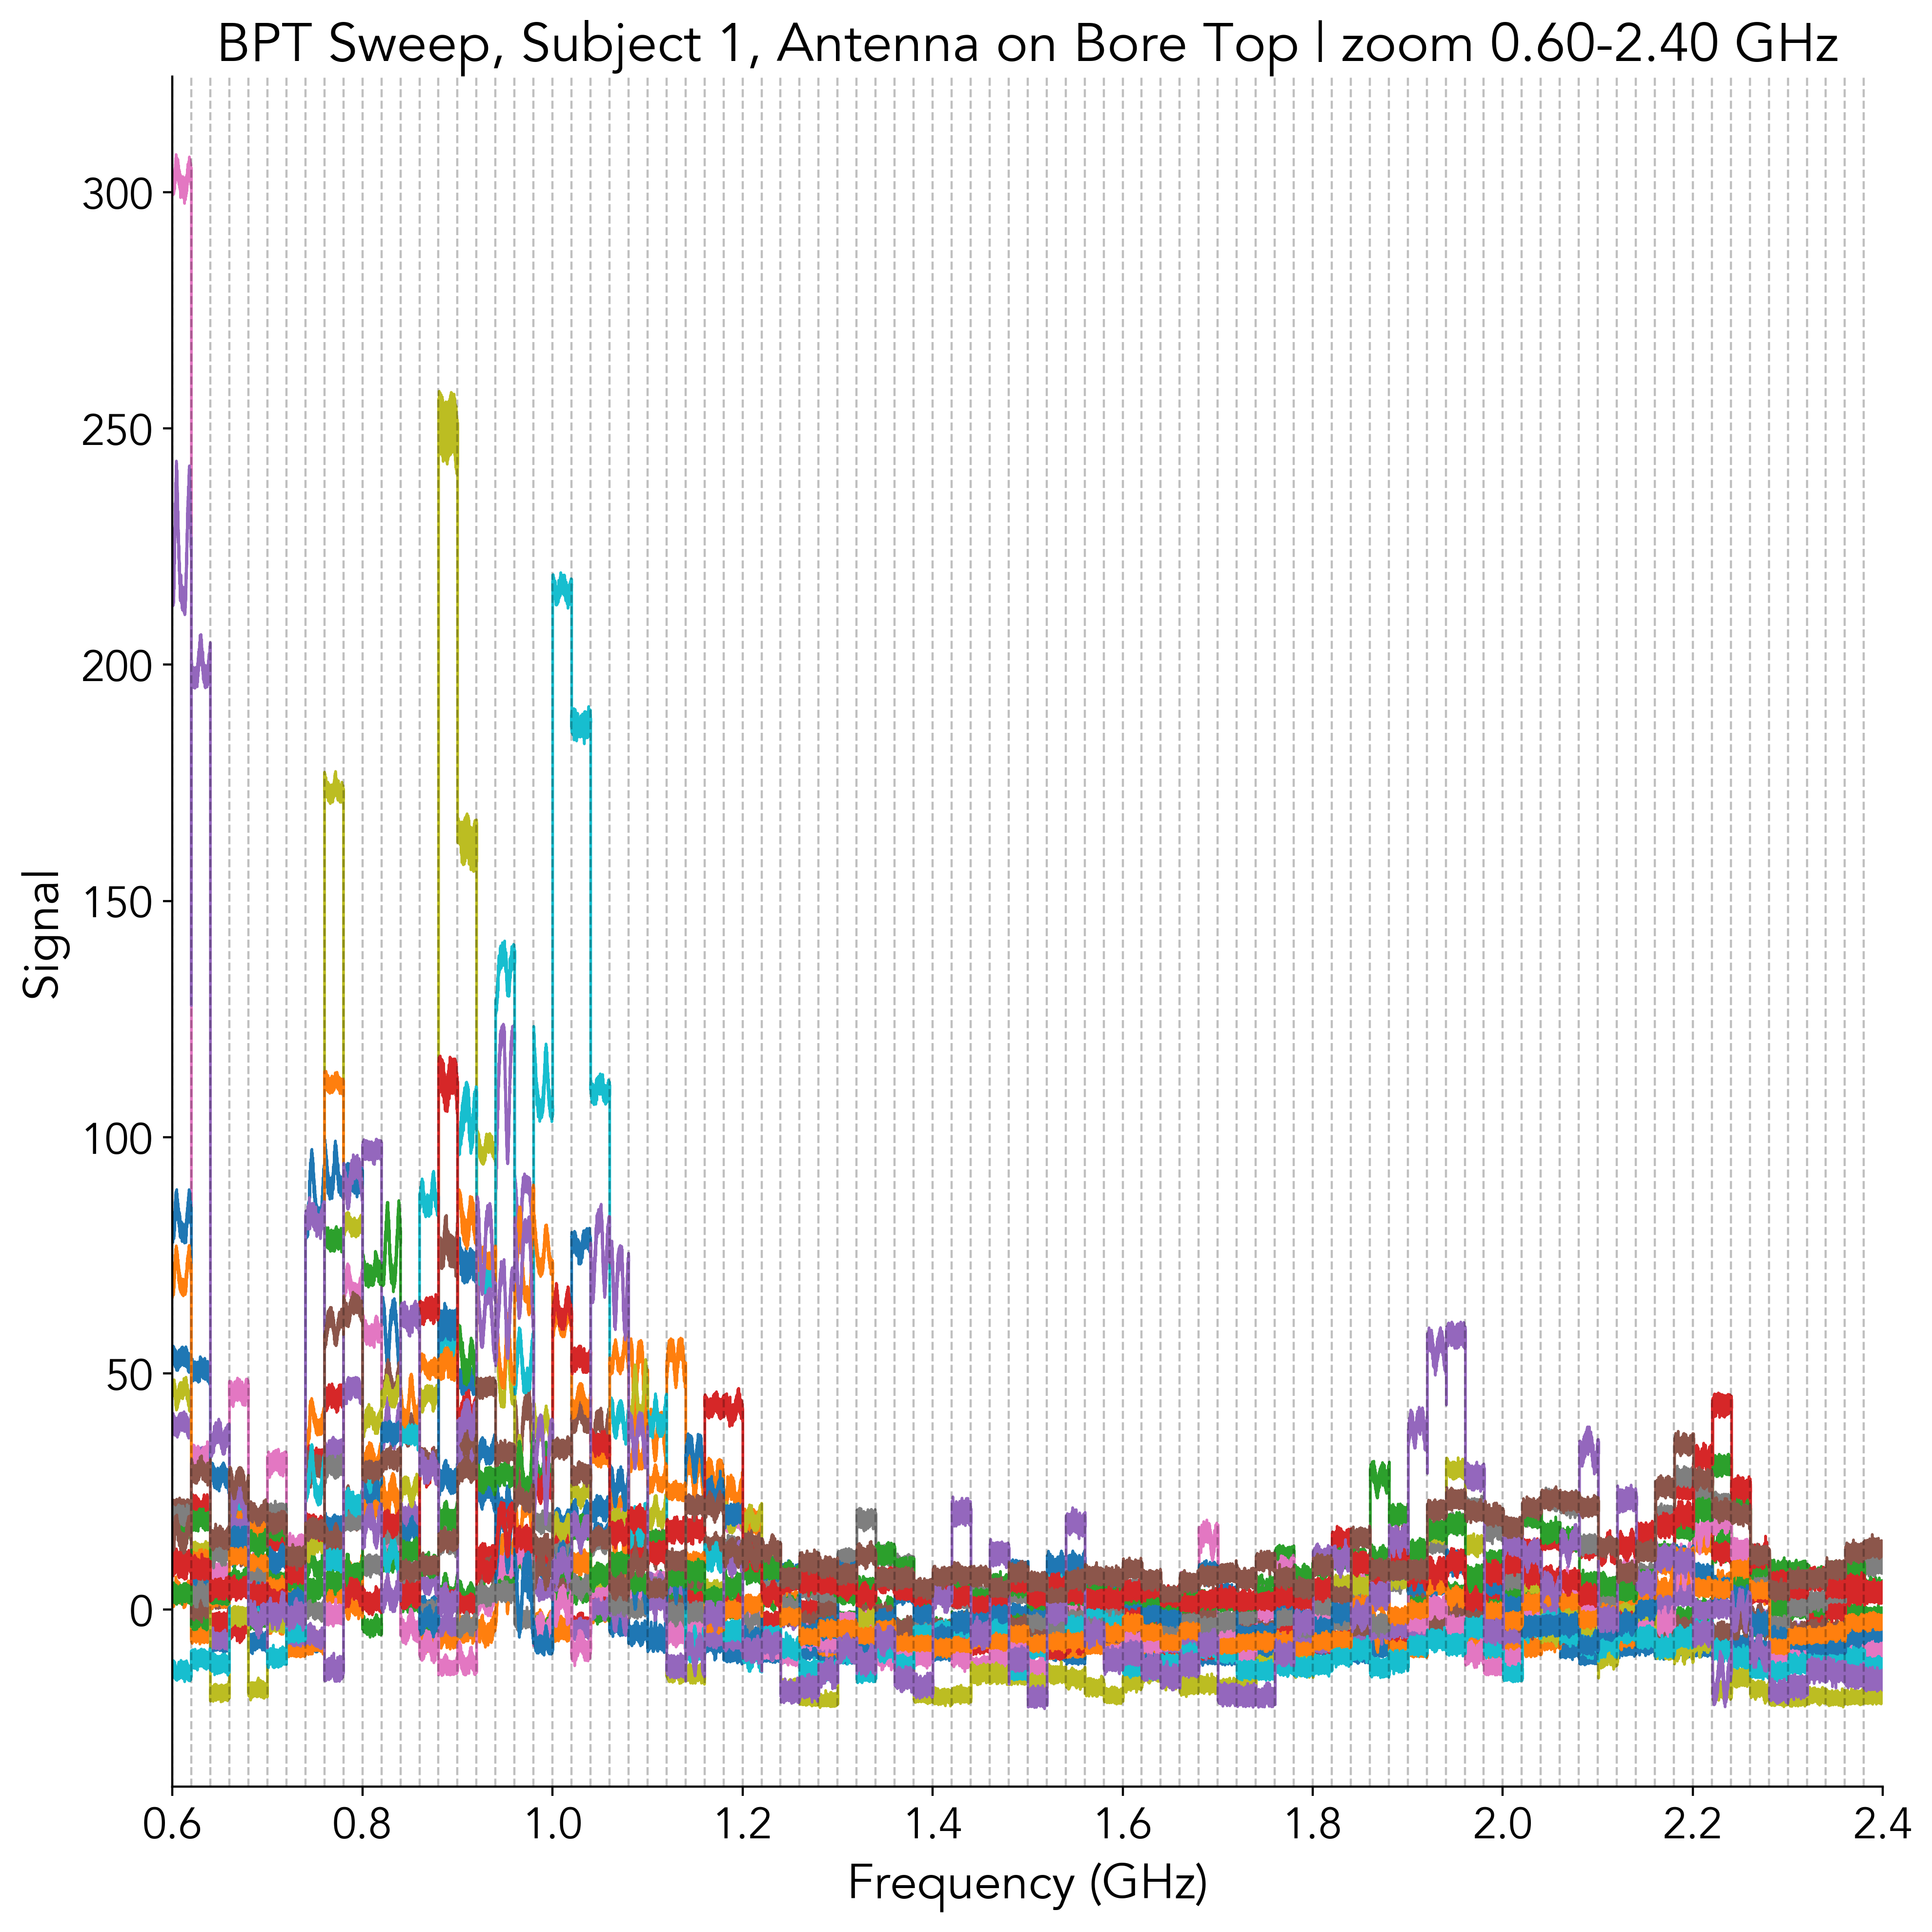

In [ ]:
%matplotlib inline
analyze_and_plot_steps(
    split_xk_bpt.bpts[0],
    figsize=(10, 10),
    tr=bssfp.metadata_dict['tr'],
    title="BPT Sweep, Subject 1, Antenna on Bore Top",
    step_time=10.0,
    shift=1e6,
    n_steps=90,
    f_start=0.6,
    f_stop=2.4,
    f_step=0.02,
    plot_f_start=None,
    plot_f_stop=None,
    dpi=400
)

#### UTE Recon Testing

In [ ]:
# add paths
from bpt_motus.io import RadialArchive
from bpt_motus.preprocessing import NoMotionReference
from bpt_motus.preprocessing import SplitXkBPT

from GERecon import Archive, Gradwarp

In [ ]:
import os
import glob
import numpy as np

def process_exam(exam_dir):
    # Find all Series directories inside the Exam folder
    series_dirs = sorted(glob.glob(os.path.join(exam_dir, "Series*")))
    
    if not series_dirs:
        print(f"No Series folders found in {exam_dir}")
        return

    for inpdir in series_dirs:
        print(f"\n" + "="*50)
        print(f"Checking {os.path.basename(inpdir)}...")

        # 1. Logic check: Does it have a Gating Track file?
        gating_files = glob.glob(os.path.join(inpdir, "*.pcvipr_track"))
        if not gating_files:
            print(f"Skipping: No gating track file found in {inpdir}")
            continue

        print(f"Found Gating Track: {os.path.basename(gating_files[0])}")

        try:
            # 2. Initialize RadialArchive
            print("Initializing RadialArchive...")
            radial = RadialArchive(inpdir) 
            radial.get_ksp(force_reload=False)

            # 3. Compress k-space
            print("Compressing k-space...")
            split_xk_bpt_nm = SplitXkBPT(inp_dir=inpdir, verbose=True)
            split_xk_bpt_nm._get_raw_xk()
            split_xk_bpt_nm.xk_cleaned = split_xk_bpt_nm.xk_ordered
            split_xk_bpt_nm._compress_kspace()
            np.save(split_xk_bpt_nm.xk_fname, split_xk_bpt_nm.xk_cleaned)

            # 4. Recon image
            print("Running NoMotionReference Recon...")
            no_motion_reference = NoMotionReference(inp_dir=inpdir, center_out=True, verbose=True)
            no_motion_reference.run(force_reload=False)
            
            print(f"Successfully processed {os.path.basename(inpdir)}")

        except Exception as e:
            print(f"Skipping {os.path.basename(inpdir)}: Failed during processing.")
            print(f"Reason: {e}")

# Example usage:
exam_path = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_ute_bpt_042826/Exam54512"
process_exam(exam_path)

INFO: Loading cached raw radial data from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_ute_bpt_042826/Exam54512/Series2...



Checking Series1...
Skipping: No gating track file found in /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_ute_bpt_042826/Exam54512/Series1

Checking Series2...
Found Gating Track: Gating_Track_190514288.pcvipr_track
Initializing RadialArchive...


INFO: Getting raw time-ordered k-space.


Compressing k-space...


INFO: Coil compressing k-space with PCA.
INFO: Reference image and CSMs not found. Extracting with crop factor 3...
INFO: Getting xk, coords, dcf, and bpts from radial data.


...

INFO: Reference image and CSMs not found. Extracting with crop factor 3...
INFO: Getting xk, coords, dcf, and bpts from radial data.
INFO: Cropping spokes by 3.
INFO: Center-out cropping selected. Cropping spoke ends, not beginnings.
INFO: Preparing adjoint NUFFT operator for 2x FOV.
INFO: Getting cartesian k-space of reference.
INFO: Getting coil sensitivity maps of reference.


Done.


INFO: Getting reference image.


SenseRecon:   0%|          | 0/30 [00:00<?, ?it/s]

Successfully processed Series7


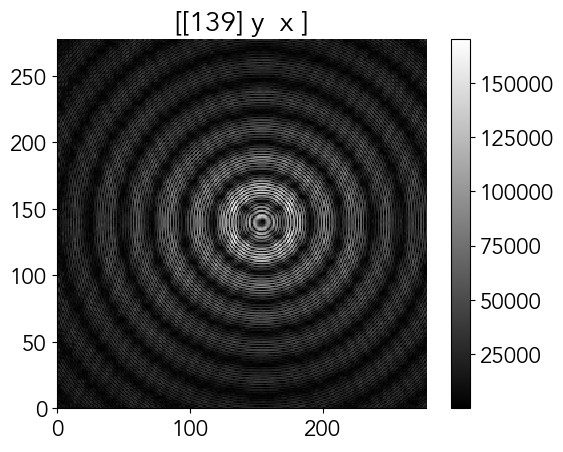

In [ ]:
%matplotlib inline
pl.ImagePlot(no_motion_reference.S.transpose(1,0,2), colormap='gray')

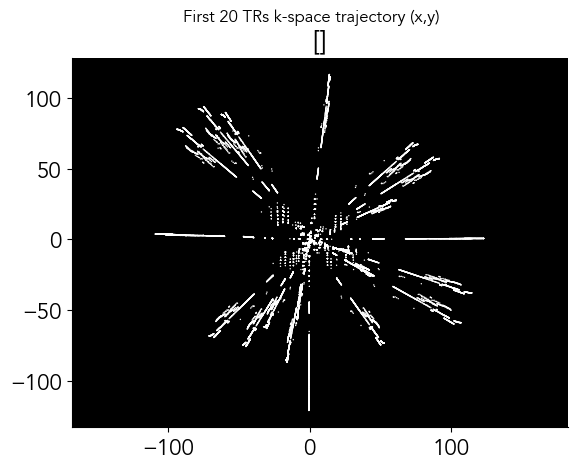

In [ ]:
pl.ScatterPlot(radial.coords_time[:20,:,:2], title="First 20 TRs k-space trajectory (x,y)")

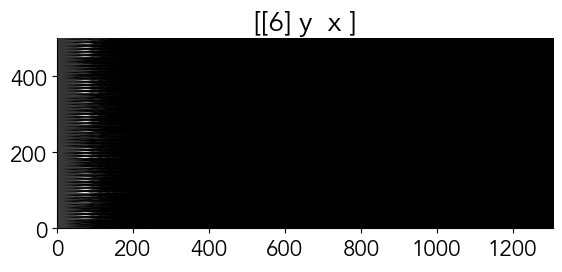

In [ ]:
pl.ImagePlot(radial.xk_time[:,:500,:])